C:\Users\benla\AppData\Local\Temp\ipykernel_7560\3844410559.py:17: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tableaux = pd.read_html(reponse.text)


Nombre d'entreprises récupérées : 503
Voici les 10 premières : ['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


[*********************100%***********************]  10 of 10 completed


<Axes: title={'center': 'Évolution du TOP 10 S&P 500 sur 30 jours'}, xlabel='Date'>

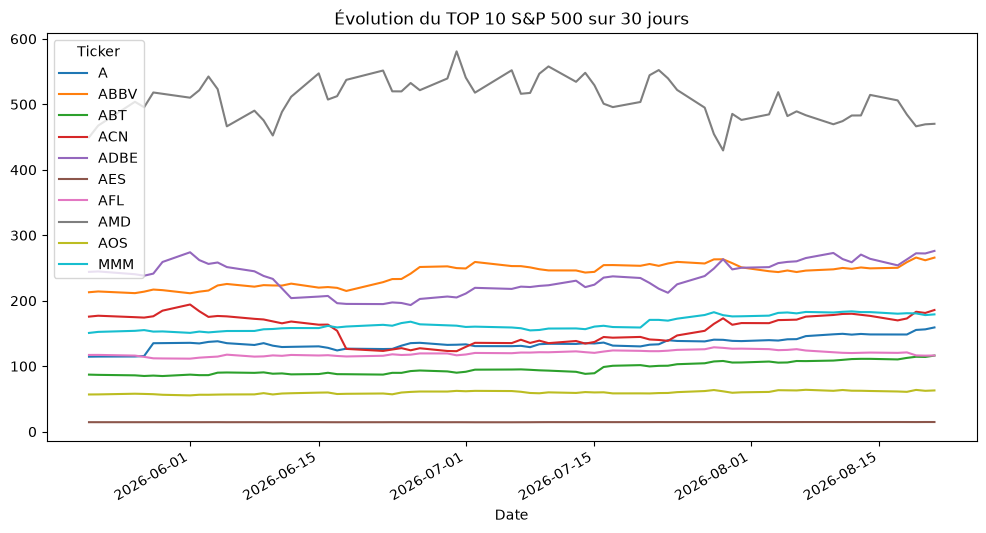

In [7]:
import pandas as pd
import yfinance as yf
import requests

"""url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
tableaux = pd.read_html(url)"""
# 1. On définit l'URL et un User-Agent (pour imiter un vrai navigateur)
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

# 2. On récupère la page web avec requests
reponse = requests.get(url, headers=headers)

# 3. On donne le texte HTML récupéré directement à Pandas
tableaux = pd.read_html(reponse.text)
# Le premier tableau de la page contient la liste des entreprises
sp500_df = tableaux[0]

# 2. Extraire uniquement les symboles (Tickers)
tickers_sp500 = sp500_df['Symbol'].tolist()

# Wikipédia utilise parfois des points (ex: BRK.B), yfinance préfère les tirets (BRK-B)
tickers_sp500 = [ticker.replace('.', '-') for ticker in tickers_sp500]

print(f"Nombre d'entreprises récupérées : {len(tickers_sp500)}")
print("Voici les 10 premières :", tickers_sp500[:10])

# On prend les 10 premières entreprises pour tester sans surcharger la connexion
top10_tickers = tickers_sp500[:10]

# Télécharger l'historique des prix sur le dernier mois
donnees_bourse = yf.download(top10_tickers, period="3mo", interval="1d")

# Afficher uniquement les prix de fermeture
prix_fermeture = donnees_bourse['Close']
prix_fermeture.head()

# Afficher l'évolution des prix sur un graphique
prix_fermeture.plot(figsize=(12, 6), title="Évolution du TOP 10 S&P 500 sur 30 jours")


